In [34]:
# Import modules.
# ---------------------------------------------------------
import pyvisa as visa
import pylab as pl
import struct
import math
import gc
# Global variables
# (Modify the following global variables according to the model).
# ---------------------------------------------------------
SDS_RSC = 'USB0::0xF4EC::0x1017::SDS08A0Q808362::INSTR'
CHANNEL = "C1"
HORI_NUM = 10
tdiv_enum = [200e-12,500e-12, 1e-9,\
 2e-9, 5e-9, 10e-9, 20e-9, 50e-9, 100e-9, 200e-9, 500e-9, \
 1e-6, 2e-6, 5e-6, 10e-6, 20e-6, 50e-6, 100e-6, 200e-6, 500e-6, \
 1e-3, 2e-3, 5e-3, 10e-3, 20e-3, 50e-3, 100e-3, 200e-3, 500e-3, \
 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]

# =========================================================
# main_desc:Analyzing waveform parameters from data blocks
# =========================================================
def main_desc(recv):
    WAVE_ARRAY_1 = recv[0x3c:0x3f + 1]
    wave_array_count = recv[0x74:0x77 + 1]
    first_point = recv[0x84:0x87 + 1]
    sp = recv[0x88:0x8b + 1]
    v_scale = recv[0x9c:0x9f + 1]
    v_offset = recv[0xa0:0xa3 + 1]
    interval = recv[0xb0:0xb3 + 1]
    code_per_div = recv[0xa4:0Xa7 + 1]
    adc_bit = recv[0xac:0Xad + 1]
    delay = recv[0xb4:0xbb + 1]
    tdiv = recv[0x144:0x145 + 1]
    probe = recv[0x148:0x14b + 1]
    data_bytes = struct.unpack('i', WAVE_ARRAY_1)[0]
    point_num = struct.unpack('i', wave_array_count)[0]
    fp = struct.unpack('i', first_point)[0]
    sp = struct.unpack('i', sp)[0]
    interval = struct.unpack('f', interval)[0]
    delay = struct.unpack('d', delay)[0]
    tdiv_index = struct.unpack('h', tdiv)[0]
    probe = struct.unpack('f', probe)[0]
    vdiv = struct.unpack('f', v_scale)[0] * probe
    offset = struct.unpack('f', v_offset)[0] * probe
    code = struct.unpack('f', code_per_div)[0]
    adc_bit = struct.unpack('h', adc_bit)[0]
    tdiv = tdiv_enum[tdiv_index]
    return vdiv, offset, interval, delay, tdiv, code, adc_bit


# =========================================================
# Main program:
# =========================================================
def main_wf_data():
    _rm = visa.ResourceManager()
    sds = _rm.open_resource(SDS_RSC)
    sds.timeout = 2000 # default value is 2000(2s)
    sds.chunk_size = 20 * 1024 * 1024 # default value is 20*1024(20k bytes)
    # Get the channel waveform parameter data blocks and parse them
    sds.write(":WAVeform:STARt 0")
    sds.write("WAV:SOUR {}".format(CHANNEL))
    sds.write("WAV:PREamble?")
    recv_all = sds.read_raw()
    recv = recv_all[recv_all.find(b'#') + 11:]
    print(len(recv))
    vdiv, ofst, interval, trdl, tdiv, vcode_per, adc_bit = main_desc(recv)
    print(vdiv, ofst, interval, trdl, tdiv,vcode_per,adc_bit)
    # Get the waveform points and confirm the number of waveform slice reads
    points = float(sds.query(":ACQuire:POINts?").strip())
    one_piece_num = float(sds.query(":WAVeform:MAXPoint?").strip())
    read_times = math.ceil(points / one_piece_num)
    #Set the number of read points per slice, if the waveform points is greater than the maximum
    # number of slice reads
    if points > one_piece_num:
        sds.write(":WAVeform:POINt {}".format(one_piece_num))
        # Choose the format of the data returned
        sds.write(":WAVeform:WIDTh BYTE")
    if adc_bit > 8:
        sds.write(":WAVeform:WIDTh WORD")
    #Get the waveform data for each slice
    recv_byte = b''
    print("read_times", read_times)
    for i in range(0, read_times):
        start = i * one_piece_num
        print("one_piece_num", one_piece_num)
        print("start", start)
        #Set the starting point of each slice
        sds.write(":WAVeform:STARt {}".format(start))
        #Get the waveform data of each slice
        sds.write("WAV:DATA?")
        recv_rtn = sds.read_raw()
        print(recv_rtn[-10:])
        print("len(recv_rtn) before rstrip", len(recv_rtn))
        # We need to get rid of the two "\n\n" at the end of the received bytes
        # However, we should not use rstrip since it's behavior is not so well defined for 
        # binary streams. But fortunately, there are always two, so we can just get rid of them
        # using slicing. 
        #recv_rtn = recv_rtn.rstrip()
        recv_rtn = recv_rtn[:-2]
        print("len(recv_rtn) after rstrip", len(recv_rtn))
        #Splice each waveform data based on data block information
        block_start = recv_rtn.find(b'#')
        data_digit = int(recv_rtn[block_start + 1:block_start + 2])
        data_start = block_start + 2 + data_digit
        recv_byte += recv_rtn[data_start:]
        print("len(recv_byte)", len(recv_byte))
    # Unpack signed byte data.
    if adc_bit > 8:
        print("points", points)
        convert_data = struct.unpack("=%dh"%points, recv_byte)
    else:
        convert_data = struct.unpack("%db"%points, recv_byte)
    del recv_byte
    gc.collect()
    #Calculate the voltage value and time value
    time_value = []
    volt_value = []
    for idx in range(0, len(convert_data)):
        volt_value.append(convert_data[idx] / vcode_per * float(vdiv) - float(ofst))
        time_data = - (float(tdiv) * HORI_NUM / 2) + idx * interval + float(trdl)
        time_value.append(time_data)
    print(len(volt_value))
    #Draw Waveform
    pl.figure(figsize=(7, 5))
    pl.plot(time_value, volt_value, markersize=2, label=u"Y-T")
    pl.legend()
    pl.grid()
    pl.show()

347
0.20000000298023224 0.0833333358168602 2.0000000233721948e-07 0.0016 0.5 7680.0 16
read_times 5
one_piece_num 5000000.0
start 0.0
b'0\x0c\x10\x0cp\x0cP\x0c\n\n'
len(recv_rtn) before rstrip 10000012
len(recv_rtn) after rstrip 10000010
len(recv_byte) 10000000
one_piece_num 5000000.0
start 5000000.0
b'\xd0\x0b \x0c\x00\x0c\x00\x0c\n\n'
len(recv_rtn) before rstrip 10000012
len(recv_rtn) after rstrip 10000010
len(recv_byte) 20000000
one_piece_num 5000000.0
start 10000000.0
b'P\x0c@\x0c\x00\x0cP\x0c\n\n'
len(recv_rtn) before rstrip 10000012
len(recv_rtn) after rstrip 10000010
len(recv_byte) 30000000
one_piece_num 5000000.0
start 15000000.0
b'`\x0c0\x0c0\x0c`\x0c\n\n'
len(recv_rtn) before rstrip 10000012
len(recv_rtn) after rstrip 10000010
len(recv_byte) 40000000
one_piece_num 5000000.0
start 20000000.0
b'\x10\x0c\x00\x0c\x00\x0c \x0c\n\n'
len(recv_rtn) before rstrip 10000012
len(recv_rtn) after rstrip 10000010
len(recv_byte) 50000000
points 25000000.0
25000000


C:\Users\gsteele\AppData\Local\miniforge3\envs\tn2211\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


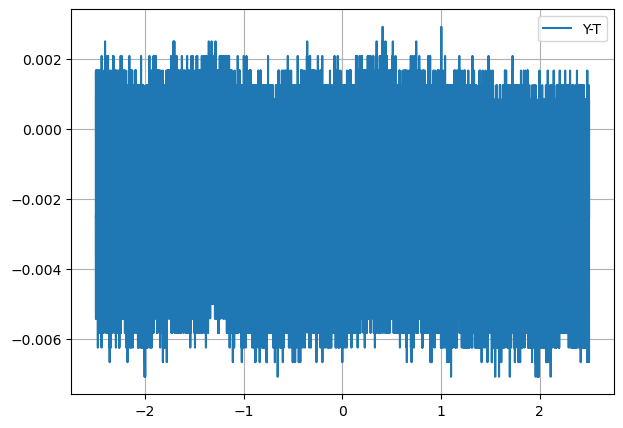

In [35]:
main_wf_data()